# Implement an End to End CNN Model for Image Classification Task.

# Task 1: Data Understanding and Visualization:

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

    • Get the list of class directories from the train folder.

    • Select one image randomly from each class.
    
    • Display the images in a grid format with two rows using matplotlib.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

dataset_dir = "/content/drive/MyDrive/AI-Sem6/week5/FruitinAmazon"
train_dir = os.path.join(dataset_dir, "train")
test_dir = os.path.join(dataset_dir, "test")

print("Train path:", train_dir)
print("Test path :", test_dir)

Train path: /content/drive/MyDrive/AI-Sem6/week5/FruitinAmazon/train
Test path : /content/drive/MyDrive/AI-Sem6/week5/FruitinAmazon/test


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

In [ ]:
# Get all class folder names from the train directory
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Classes found:", class_names)
print("Number of classes:", len(class_names))

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [ ]:
# Select one random image from each class
sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    # Get image files from this class folder
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Pick one random image
    random_image = random.choice(image_files)
    image_path = os.path.join(class_path, random_image)

    sample_images.append((class_name, image_path))

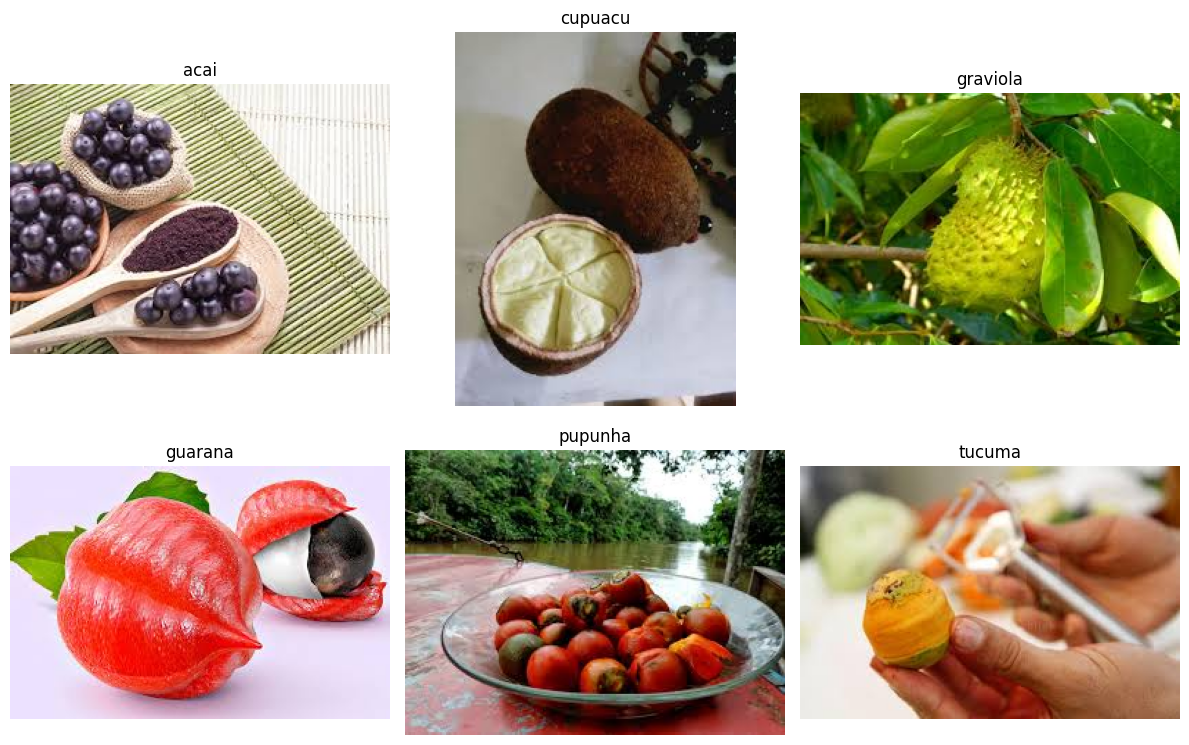

In [ ]:
# Display images in a grid with two rows
num_classes = len(sample_images)
rows = 2
cols = int(np.ceil(num_classes / rows))

plt.figure(figsize=(4 * cols, 8))

for i, (class_name, image_path) in enumerate(sample_images):
    img = Image.open(image_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

• Hint:

    – Iterate through each class subdirectory and check if each image is valid.

    – Use the Image.open() function to attempt to load each image.

    – If the image is corrupted i.e raises an IOError or SyntaxError, remove the image from the directory and print f"Removed corrupted image: {image_path}".

    – Maintain a list of all corrupted image paths for reporting.
    
• Expected Output: No corrupted images found.

In [ ]:
# Function to check and remove corrupted images from a directory
def remove_corrupted_images(data_dir):
    corrupted_images = []

    # Go through each class folder
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)

        if os.path.isdir(class_path):
            for file_name in os.listdir(class_path):
                image_path = os.path.join(class_path, file_name)

                # Only check image files
                if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                    try:
                        # Try opening and verifying the image
                        img = Image.open(image_path)
                        img.verify()
                    except (IOError, SyntaxError, OSError):
                        corrupted_images.append(image_path)
                        os.remove(image_path)
                        print(f"Removed corrupted image: {image_path}")

    # Final message
    if len(corrupted_images) == 0:
        print("No Corrupted Images Found.")

    return corrupted_images

In [ ]:
# Check train and test folders
print("Checking training images...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test images...")
test_corrupted = remove_corrupted_images(test_dir)

Checking training images...
No Corrupted Images Found.

Checking test images...
No Corrupted Images Found.


# Task 2: Loading and Preprocessing Image Data in keras:

In [ ]:
# Basic settings from worksheet
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

# Normalize pixel values from [0,255] to [0,1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

In [ ]:
# Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123
)

# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

# Create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False
)



Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [ ]:
# Save class names BEFORE normalization
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [ ]:
# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Task 3 - Implement a CNN with
Follow the following Structure and Hyper - parameters:

**Convolutional Architecture:**

• Convolutional Layer 1:

    – Filter Size (F): (3, 3)
    – Number of Filters (k): 32
    – Padding (P): same
    – Stride (s): 1
• Activation Layer: ReLU activation

• Pooling Layer 1: Max pooling

    – Filter Size (F): (2, 2)
    – Stride (s): 2
• Convolutional Layer 2:

    – Filter Size (F): (3, 3)
    – Number of Filters (k): 32
    – Padding (P): same
    – Stride (s): 1
• Activation Layer: ReLU activation

• Pooling Layer 2: Max pooling

    – Filter Size (F): (2, 2)
    – Stride (s): 2
**Fully Connected Network Architecture:**

• Flatten Layer: Flatten the input coming from the convolutional layers

• Input Layer:

• Hidden Layer - 2:

    – Number of Neurons: 64
    – Number of Neurons: 128
• Output Layer:

    – Number of Neurons: num classes (number of output classes)

In [ ]:
# Build CNN model based on worksheet structure
model = keras.Sequential([
    # Input + first convolution block
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Second convolution block
    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Fully connected layers
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),

    # Output layer
    layers.Dense(num_classes, activation="softmax")
])

# Show model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the Model
**Model Compilation**

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [ ]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Task 4: Train the Model
**Model Training**

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [ ]:
# Callbacks
checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",          # save best model to file
    monitor="val_accuracy",         # check validation accuracy
    save_best_only=True,            # only keep best model
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",             # stop if validation loss stops improving
    patience=15,                    # wait 15 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.1604 - loss: 2.0089
Epoch 1: val_accuracy improved from None to 0.72222, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 460ms/step - accuracy: 0.1667 - loss: 2.0112 - val_accuracy: 0.7222 - val_loss: 1.4992
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.3569 - loss: 1.7002
Epoch 2: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step - accuracy: 0.3472 - loss: 1.6552 - val_accuracy: 0.5000 - val_loss: 1.6131
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.5455 - loss: 1.4323
Epoch 3: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - accuracy: 0.5972 - loss: 1.3759 - val_accuracy: 0.6111 - val_loss: 1.3606
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.7135 - loss: 1.0520
Epoch 4: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 566ms/step - accuracy: 0.7083 - loss: 1.0041 - val_accuracy: 0.6667 - val_loss: 1.0932
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.7497 - loss:


Epoch 6: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 595ms/step - accuracy: 0.8750 - loss: 0.4715 - val_accuracy: 0.7778 - val_loss: 0.7910
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.7983 - loss: 0.3874
Epoch 7: val_accuracy improved from 0.77778 to 0.88889, saving model to best_fruit_model.h5



Epoch 7: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 362ms/step - accuracy: 0.7778 - loss: 0.4658 - val_accuracy: 0.8889 - val_loss: 0.3986
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9840 - loss: 0.1527
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 0.9722 - loss: 0.1496 - val_accuracy: 0.8333 - val_loss: 0.5462
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 1.0000 - loss: 0.1030
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 557ms/step - accuracy: 1.0000 - loss: 0.1047 - val_accuracy: 0.8333 - val_loss: 0.3043
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9837 - loss: 0.0735
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 396ms/step - accuracy: 0.9861 - loss: 0.0753 - val_accuracy: 0.8889 - val_loss: 0.2993
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 1.0000 - lo

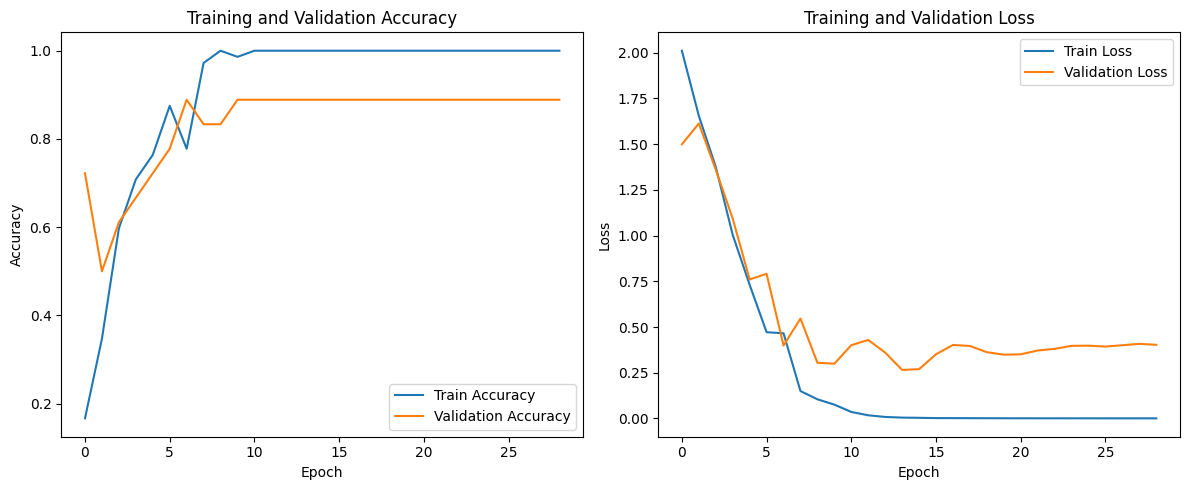

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Task 5: Evaluate the Model
**Model Evaluation**

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [ ]:
# Evaluate the trained model on test data
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8333 - loss: 0.5822
Test Loss: 0.5821966528892517
Test Accuracy: 0.8333333134651184


# Task 6: Save and Load the Model
**Model Saving and Loading**

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [ ]:
# Save the final model
model.save("final_fruit_model.h5")
print("Model saved successfully.")

# Load the saved model
loaded_model = keras.models.load_model("final_fruit_model.h5")
print("Model loaded successfully.")

Model saved successfully.
Model loaded successfully.


In [ ]:
# Re-evaluate the loaded model
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_test_loss)
print("Loaded Model Test Accuracy:", loaded_test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.8333 - loss: 0.5822
Loaded Model Test Loss: 0.5821966528892517
Loaded Model Test Accuracy: 0.8333333134651184


# Task 7: Predictions and Classification Report
**Making Predictions**

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification Report of your Model Performance.

In [ ]:
# Get true labels and predicted labels
y_true = []
y_pred = []

for images, labels in test_ds:
    # Predict probabilities for this batch
    predictions = loaded_model.predict(images)

    # Convert probabilities to class index
    predicted_labels = np.argmax(predictions, axis=1)

    # Store results
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


In [ ]:
# Print classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       0.67      0.80      0.73         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.83        30
   macro avg       0.87      0.83      0.82        30
weighted avg       0.87      0.83      0.82        30



## Conclusion

In conclusion, this worksheet successfully demonstrated the complete process of building an end-to-end CNN model for image classification. First, the fruit dataset was explored and visualized, and corrupted images were checked to make sure the data was suitable for training. Then the images were preprocessed by resizing, batching, and normalizing them before feeding them into the CNN model.

The CNN was built using the required convolutional, pooling, flatten, and dense layers, then compiled and trained using TensorFlow and Keras. After training, the model was evaluated on the test data, saved, loaded again, and used for prediction. The classification report gave a detailed summary of the model’s performance on each class.

Overall, this task helped in understanding how CNNs can automatically learn image features and perform classification effectively. It also provided practical experience in the full machine learning workflow, from data preparation to final evaluation.